In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;
using JJDFTX: kinetic_energy
interpolate = pyimport("scipy.interpolate").interp1d

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


PyObject <class 'scipy.interpolate.interpolate.interp1d'>

In [7]:
phonon11_dir = "../phonon11/"
phonon22_dir = "../phonon22/";
phonon33_dir = "../phonon33/";

In [13]:
force_matrix11, cellph_map11 = phonon_force_matrix(phonon11_dir*"BN3NC");
force_matrix22, cellph_map22 = phonon_force_matrix(phonon22_dir*"BN3NC");
force_matrix33, cellph_map33 = phonon_force_matrix(phonon33_dir*"BN3NC");

In [14]:
dispersion11 = phonon_dispersion(force_matrix11, cellph_map11);
dispersion22 = phonon_dispersion(force_matrix22, cellph_map22);
dispersion33 = phonon_dispersion(force_matrix33, cellph_map33);

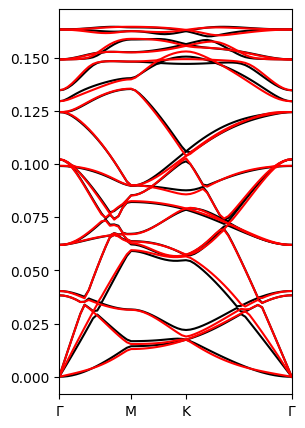

(0.0, 55.0)

In [15]:
figure(figsize=(3, 5))
plot(dispersion33, color="black")
plot(dispersion22, color="red")
label_plots()

In [22]:
export_hwannier(phonon33_dir*"wannier")
export_momentum(phonon33_dir*"wannier")
export_heph(phonon33_dir*"wannier");

In [19]:
?export

search: export export_heph export_momentum export_hwannier



```
export
```

`export` is used within modules to tell Julia which functions should be made available to the user. For example: `export foo` makes the name `foo` available when [`using`](@ref) the module. See the [manual section about modules](@ref modules) for details.


In [17]:
Hwannier, cellmap = hwannier(phonon22_dir*"wannier"), np.loadtxt(phonon22_dir*"wannier.map.txt");

In [22]:
Energies, DOS = density_of_states(Hwannier, cellmap, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=500)

([-7.748071188102736, -7.7380637561977235, -7.72805632429271, -7.718048892387697, -7.708041460482683, -7.69803402857767, -7.688026596672656, -7.678019164767643, -7.668011732862629, -7.658004300957616  …  -3.3047714222767945, -3.2947639903717816, -3.2847565584667677, -3.2747491265617548, -3.264741694656741, -3.254734262751728, -3.244726830846714, -3.234719398941701, -3.2247119670366873, -3.2147045351316743], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [42]:
Es, Cs = find_chemical_potential(Energies, DOS)
μ = Energies[argmin(abs.(Cs .- 0.5))]
println("Chemical potential: $(μ)")
println("gμ: $(DOS[argmin(abs.(Energies .- μ))])")

Chemical potential: -5.7766071028151
gμ: 0.9455000000000001


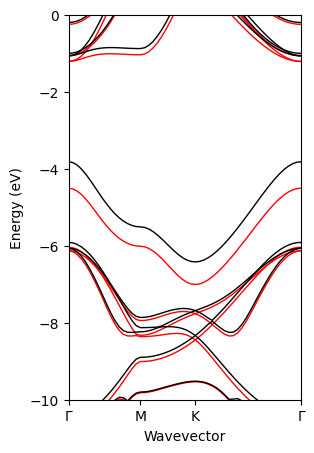

In [36]:
figure(figsize=(3, 5))
plot_bands("../BN3NC.bands.eigenvals", spin=2, linewidth=1, color_up="red", color_dn="black")
ylim(-10, 0);

In [44]:
# Find JDOS
fomega = interpolate(Energies .- μ, DOS);

In [45]:
JDOS = Float64[]
omegarange = range(0, 1, length=100)
for ω in omegarange
    push!(JDOS, pyintegrate.quad(x->fomega(x)[1]*fomega(x-ω)[1], 0, ω)[1])
end

In [52]:
meshing=20
num_blocks=1000
histogram_width=100

Alternative_JDOS = zeros(100)
for i in 1:num_blocks
    k = vcat(rand(2, meshing^2), zeros(1, meshing^2))
    kprime = vcat(rand(2, meshing^2), zeros(1, meshing^2))

    eks = wannier_bands(Hwannier, cellmap, k)[1]
    ekprimes = wannier_bands(Hwannier, cellmap, kprime)[1]
    eks = np.repeat(np.reshape(eks, (meshing^2, 1) ), meshing^2, axis=1)
    ekprimes = np.repeat(np.reshape(ekprimes, (1, meshing^2) ),meshing^2,  axis=0)
    f2 = 1 .- np.heaviside(μ .- ekprimes, 0.5)
    f1 = np.heaviside(μ .- eks, 0.5)

    Alternative_JDOS += first(np.histogram(ekprimes-eks, bins=round(Int, histogram_width), weights=f1 .* f2, range=(0, 1)))*(1/meshing)^4*histogram_width*(1/num_blocks)
end

In [54]:
np.savetxt("JDOS.txt", hcat(omegarange[2:end], JDOS[2:end], Alternative_JDOS[2:end]), header="omegas, jdos, jdos_alternative")

In [17]:
Energies_up, DOS_up = density_of_states(HwannierUp, cellmapUp, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=1000)
Energies_dn, DOS_dn = density_of_states(HwannierDn, cellmapDn, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=1000)

([-7.422544278544206, -7.412541255290975, -7.402538232037744, -7.392535208784513, -7.382532185531282, -7.3725291622780516, -7.362526139024821, -7.352523115771589, -7.342520092518359, -7.332517069265128  …  -2.921183814590317, -2.9111807913370864, -2.9011777680838557, -2.891174744830625, -2.8811717215773935, -2.871168698324163, -2.8611656750709322, -2.8511626518177016, -2.84115962856447, -2.8311566053112394], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

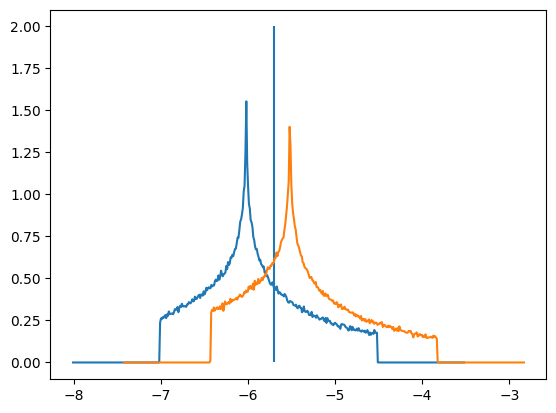

PyObject <matplotlib.collections.LineCollection object at 0x7f35689390d0>

In [61]:
plot(Energies_up, DOS_up)
plot(Energies_dn, DOS_dn)
vlines([-5.7], 0, 2)

In [31]:
Es_up, Cs_up = find_chemical_potential(Energies_up, DOS_up)
Es_dn, Cs_dn = find_chemical_potential(Energies_dn, DOS_dn);

In [32]:
f_up =  interpolate(Es_up, Cs_up)
f_dn =  interpolate(Es_dn, Cs_dn)

PyObject <scipy.interpolate.interpolate.interp1d object at 0x7f3564fad540>

In [49]:
Energies = collect(range(-6.5, -3.6, length=10000))
Cs_tot = first.(f_up.(Energies)) + first.(f_dn.(Energies));
μ = Energies[argmin(abs.(Cs_tot .- 1))]
println("Chemical potential: $(μ)")
println("gμ: $(DOS_up[argmin(abs.(Energies_up .- μ))]+ DOS_dn[argmin(abs.(Energies_dn .- μ))])")

Chemical potential: -5.682408240824082
gμ: 1.0550000000000002


In [45]:
# Check
Cs_up[argmin(abs.(Es_up .+ 5.682408))]+Cs_dn[argmin(abs.(Es_dn .+ 5.682408))]

1.001818816268245

In [16]:
# Drude Conductivity
es_up, cs_up = drude_conductivity(lattice_vectors, HwannierUp, cellmapUp, PwannierUp, mesh=20, num_blocks=500,
    degeneracy=1, histogram_width=100)
es_dn, cs_dn = drude_conductivity(lattice_vectors, HwannierDn, cellmapDn, PwannierDn, mesh=20, num_blocks=500,
    degeneracy=1, histogram_width=100);

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

Block: 266
Block: 267
Block: 268
Block: 269
Block: 270
Block: 271
Block: 272
Block: 273
Block: 274
Block: 275
Block: 276
Block: 277
Block: 278
Block: 279
Block: 280
Block: 281
Block: 282
Block: 283
Block: 284
Block: 285
Block: 286
Block: 287
Block: 288
Block: 289
Block: 290
Block: 291
Block: 292
Block: 293
Block: 294
Block: 295
Block: 296
Block: 297
Block: 298
Block: 299
Block: 300
Block: 301
Block: 302
Block: 303
Block: 304
Block: 305
Block: 306
Block: 307
Block: 308
Block: 309
Block: 310
Block: 311
Block: 312
Block: 313
Block: 314
Block: 315
Block: 316
Block: 317
Block: 318
Block: 319
Block: 320
Block: 321
Block: 322
Block: 323
Block: 324
Block: 325
Block: 326
Block: 327
Block: 328
Block: 329
Block: 330
Block: 331
Block: 332
Block: 333
Block: 334
Block: 335
Block: 336
Block: 337
Block: 338
Block: 339
Block: 340
Block: 341
Block: 342
Block: 343
Block: 344
Block: 345
Block: 346
Block: 347
Block: 348
Block: 349
Block: 350
Block: 351
Block: 352
Block: 353
Block: 354
Block: 355
Block: 356

In [17]:
cs_up_ave = (cs_up[argmin(abs.(es_up .+ 5.682408)), 2, 2]+cs_up[argmin(abs.(es_up .+ 5.682408)), 1, 1])/2
cs_dn_ave = (cs_dn[argmin(abs.(es_dn .+ 5.682408)), 2, 2]+cs_dn[argmin(abs.(es_up .+ 5.682408)), 1, 1])/2
cs_up_ave + cs_dn_ave

1.189916088423283

In [18]:
println("The conductivity is $(100*1.189916088423283/(2/pi))% of graphene at 0.5 eV doping") 

The conductivity is 186.9115820889444% of graphene at 0.5 eV doping


In [50]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierUp, cellmapUp, lattice_vectors, k, -5.682408240824082, Val(2), histogram_width=100, mesh=50, 
            degeneracy=1, monte_carlo=true)+ImΠ(HwannierDn, cellmapDn, lattice_vectors, k, -5.682408240824082, Val(2), histogram_width=100, mesh=50, 
            degeneracy=1, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
[0.10

In [51]:
energies = range(0, 100, length=10000)
energies = collect(energies)
epsilons_default = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    println(i); flush(stdout)
    for (j, ω) in enumerate(range(0.05, 5, length=100))
        epsilons_default[i, j] = abs(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=1), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [54]:
plasmon_default = [range(0.05, 5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

In [63]:
np.savetxt("plasmon.txt", hcat(qs, plasmon_default), header="default")

In [64]:
qs, plasmon_default = collect.([col for col in eachcol(np.loadtxt("plasmon.txt"))]);

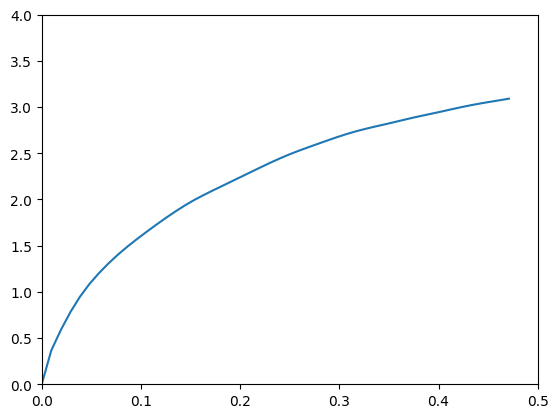

(0.0, 4.0)

In [65]:
plot(qs, plasmon_default)
xlim(0, 0.5)
ylim(0, 4)

In [25]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("../phonon11/tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen11 = 1 ./ tau_allen_inv;

In [26]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("../phonon22/tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen22 = 1 ./ tau_allen_inv;

In [27]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("../phonon33/tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen33 = 1 ./ tau_allen_inv;

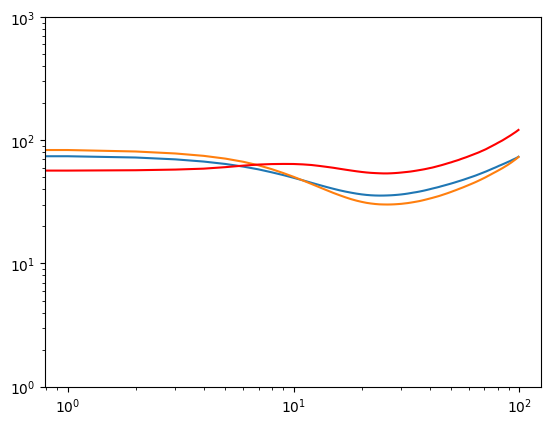

(1, 1000)

In [29]:
loglog(tau_allen11)
loglog(tau_allen22)
loglog(tau_allen33, color="red")

ylim(1, 1000)

In [37]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau_allen22));